In [2]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All Libraries Imported Successfully!")

All Libraries Imported Successfully!


Dataset loading

In [3]:
# Load dataset
df = pd.read_csv("GOOGL_2004-08-01_2024-12-18.csv")
print("Dataset Loaded Successfully! ")
print("Shape:", df.shape)

Dataset Loaded Successfully! 
Shape: (5118, 7)


In [4]:
# See first 5 rows
# This shows us what the data looks like
print("First 5 rows:")
df.head()

First 5 rows:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,2.502503,2.604104,2.401401,2.511011,2.501941,893181924
1,2004-08-20,2.527778,2.729730,2.515015,2.710460,2.700670,456686856
2,2004-08-23,2.771522,2.839840,2.728979,2.737738,2.727849,365122512
3,2004-08-24,2.783784,2.792793,2.591842,2.624374,2.614895,304946748
4,2004-08-25,2.626627,2.702703,2.599600,2.652653,2.643072,183772044


In [5]:
# Check basic info
# This tells us column names, data types and missing values
print("Column Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Column Names: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data Types:
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Basic Statistics:


,Open,High,Low,Close,Adj Close,Volume
count,5118.000000,5118.000000,5118.000000,5118.000000,5118.000000,5.118000e+03
mean,47.639701,48.139771,47.149358,47.654613,47.490963,1.157640e+08
std,45.736050,46.241037,45.269941,45.763431,45.621100,1.470189e+08
min,2.482232,2.546046,2.401401,2.502753,2.493713,9.312000e+06
25%,13.176239,13.307683,13.039790,13.182808,13.135192,3.064900e+07
50%,28.003501,28.195346,27.751500,27.969750,27.868724,5.752321e+07
75%,62.746125,63.414874,62.220124,62.900626,62.673431,1.393135e+08
max,197.250000,201.419998,194.979996,196.660004,196.660004,1.643023e+09


In [6]:
# Convert Date column to proper date format
# Right now Date is text — we need to make it a real date
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date — oldest to newest
df = df.sort_values('Date')

# Reset index
df = df.reset_index(drop=True)

print("Data Cleaned Successfully!")
print("Date range:", df['Date'].min(), "to", df['Date'].max())

Data Cleaned Successfully!
Date range: 2004-08-19 00:00:00 to 2024-12-17 00:00:00


Visualizations

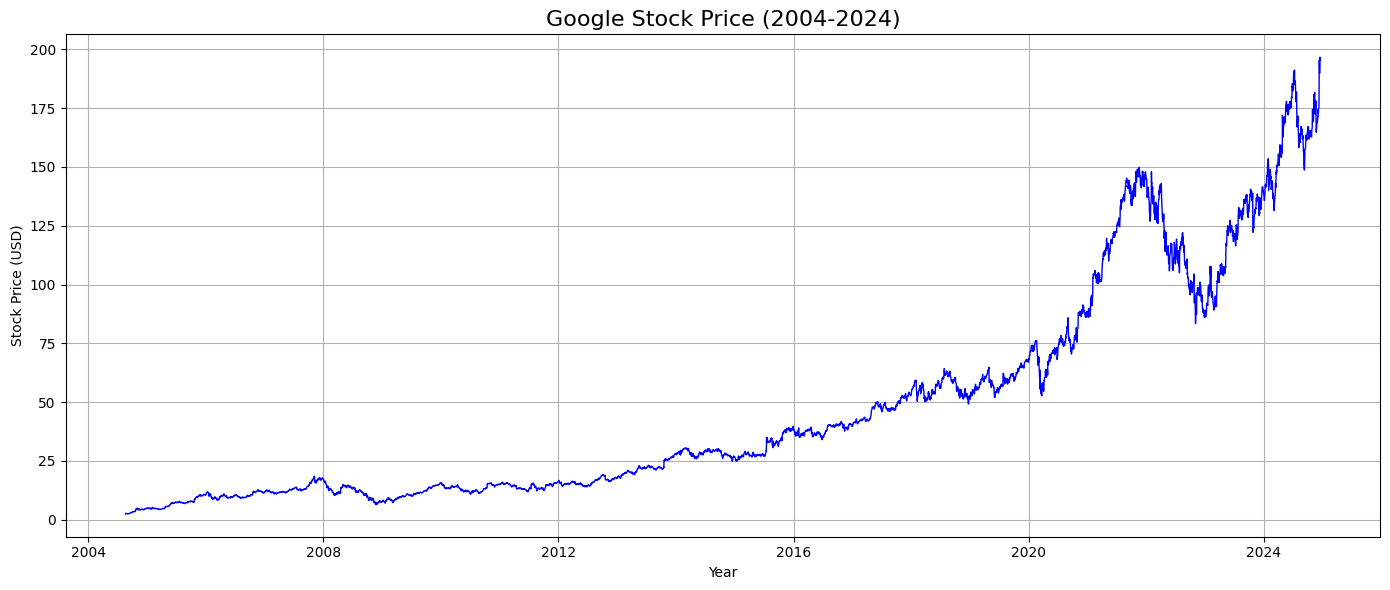

In [7]:
# Chart 1 - Google Stock Price Over 20 Years
# This shows how Google stock grew from 2004 to 2024
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'],
         color='blue', linewidth=1)
plt.title("Google Stock Price (2004-2024)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Stock Price (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

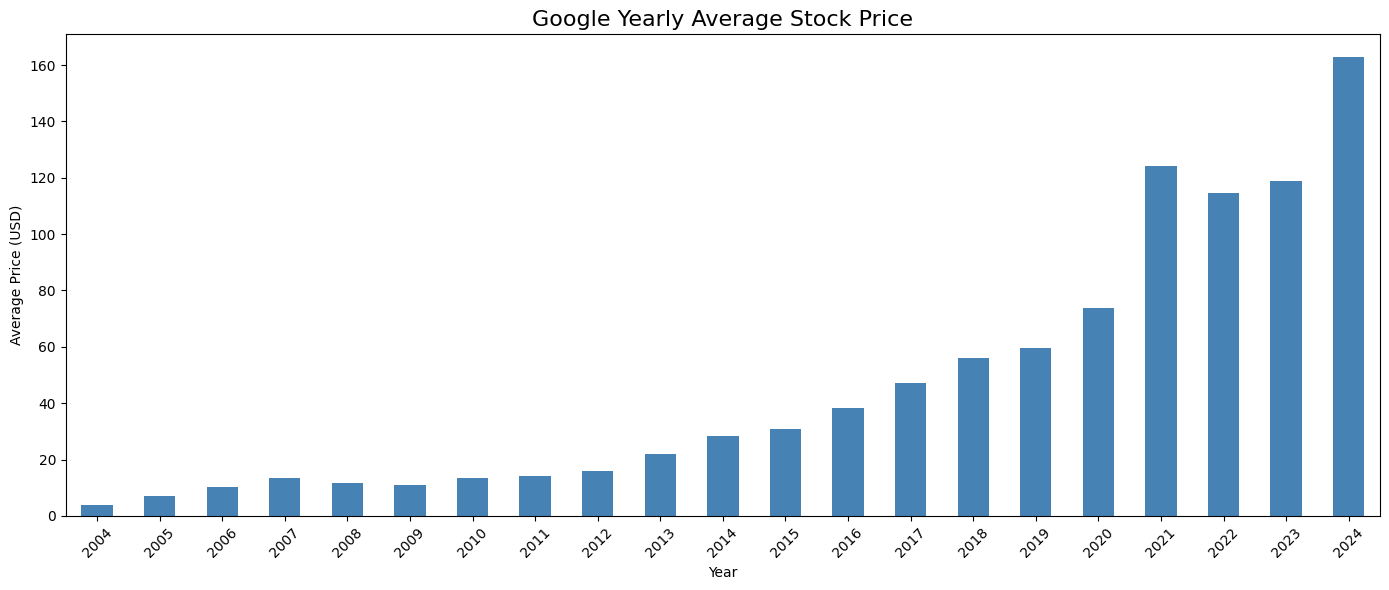

In [8]:
# Chart 2 - Yearly Average Stock Price
# This shows average price for each year
df['Year'] = df['Date'].dt.year

plt.figure(figsize=(14,6))
df.groupby('Year')['Close'].mean().plot(kind='bar',
                                         color='steelblue')
plt.title("Google Yearly Average Stock Price", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

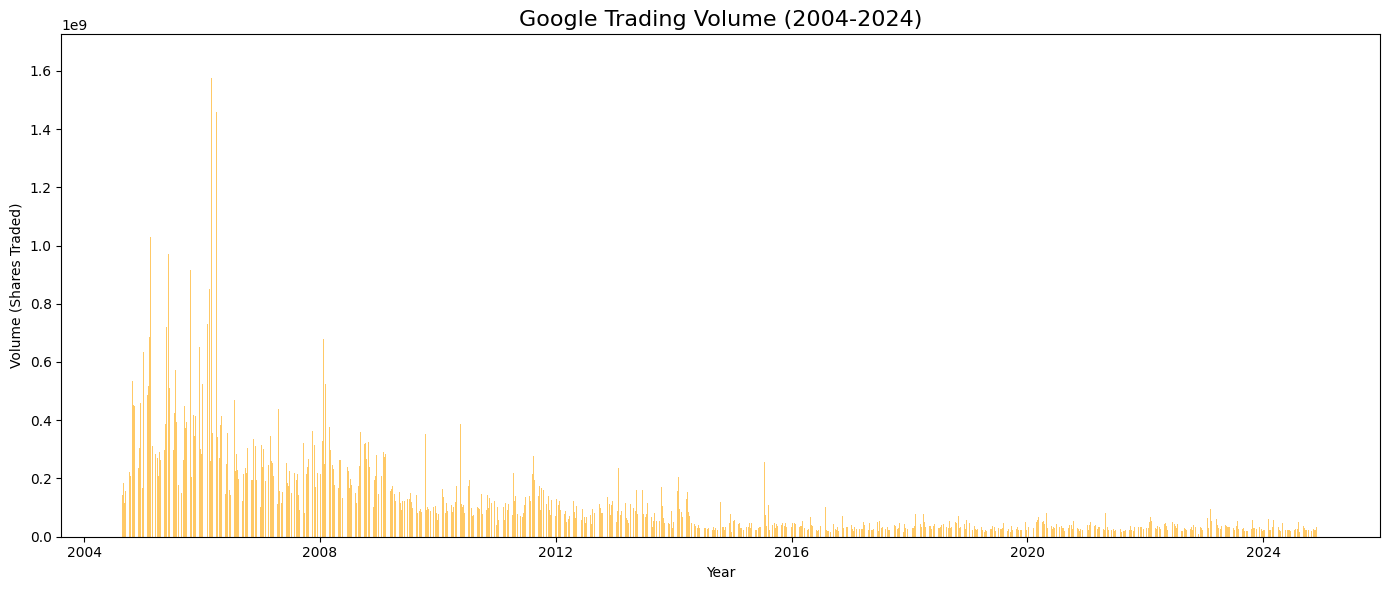

In [9]:
# Chart 3 - Trading Volume Over Time
# Volume means how many shares were bought/sold each day
# High volume = more people interested in the stock!
plt.figure(figsize=(14,6))
plt.bar(df['Date'], df['Volume'],
        color='orange', alpha=0.6)
plt.title("Google Trading Volume (2004-2024)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Volume (Shares Traded)")
plt.tight_layout()
plt.show()

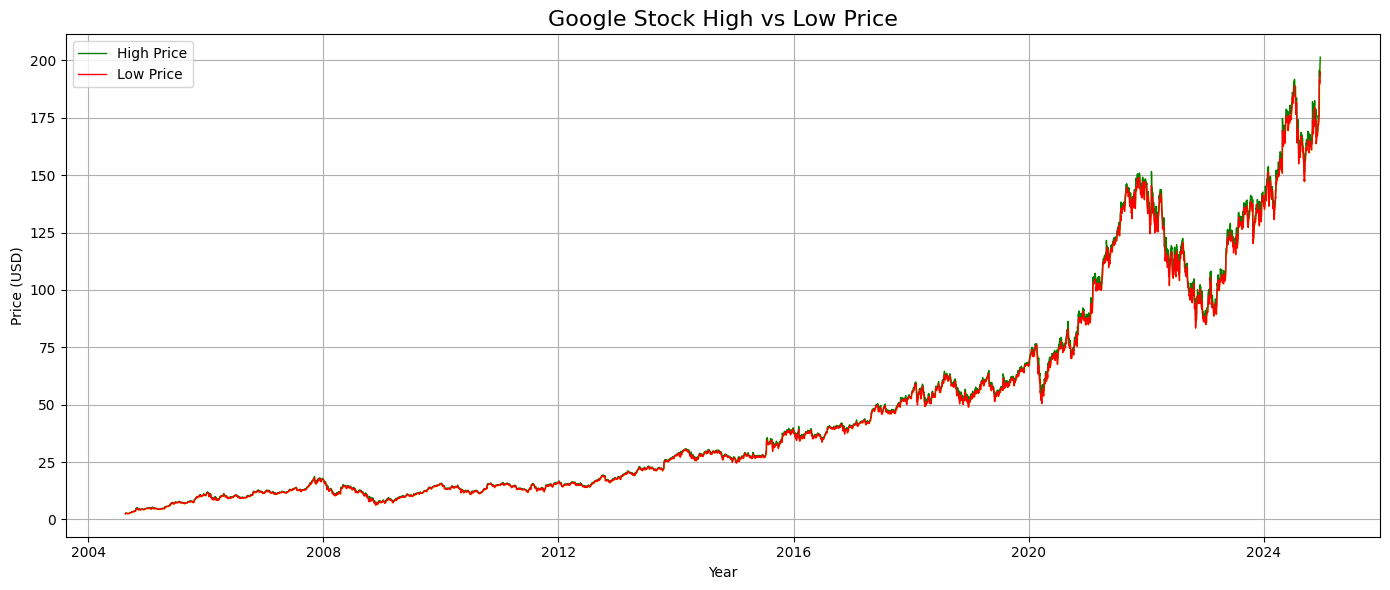

In [10]:
# Chart 4 - Daily High vs Low Price
# This shows the price range each year
# Green = Highest price, Red = Lowest price
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['High'],
         color='green', label='High Price', linewidth=1)
plt.plot(df['Date'], df['Low'],
         color='red', label='Low Price', linewidth=1)
plt.fill_between(df['Date'], df['High'], df['Low'],
                  alpha=0.3, color='yellow')
plt.title("Google Stock High vs Low Price", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

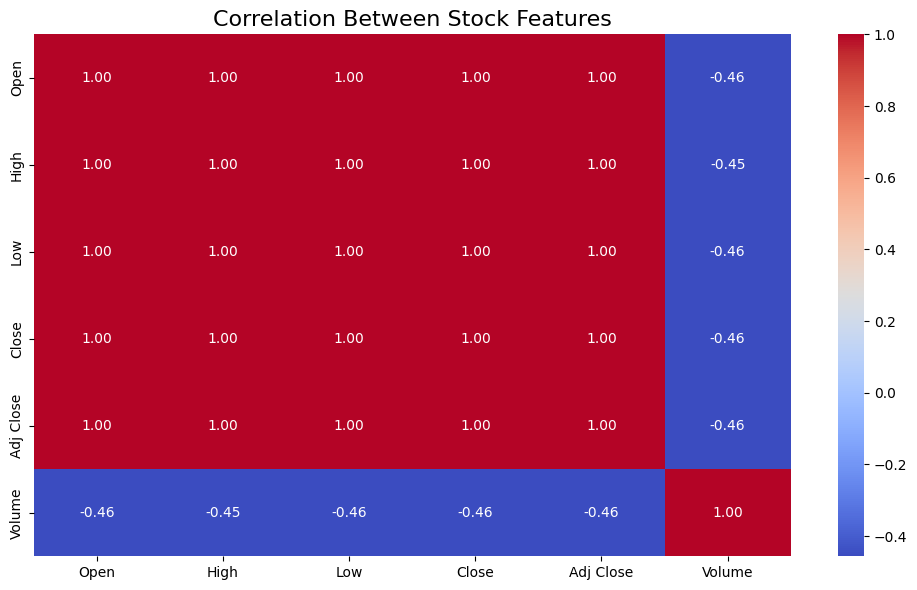

In [11]:
# Chart 5 - Correlation Heatmap
# This shows how strongly columns are related to each other
# Values close to 1.0 = strongly related
plt.figure(figsize=(10,6))
sns.heatmap(df[['Open','High','Low','Close',
                'Adj Close','Volume']].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlation Between Stock Features", fontsize=16)
plt.tight_layout()
plt.show()

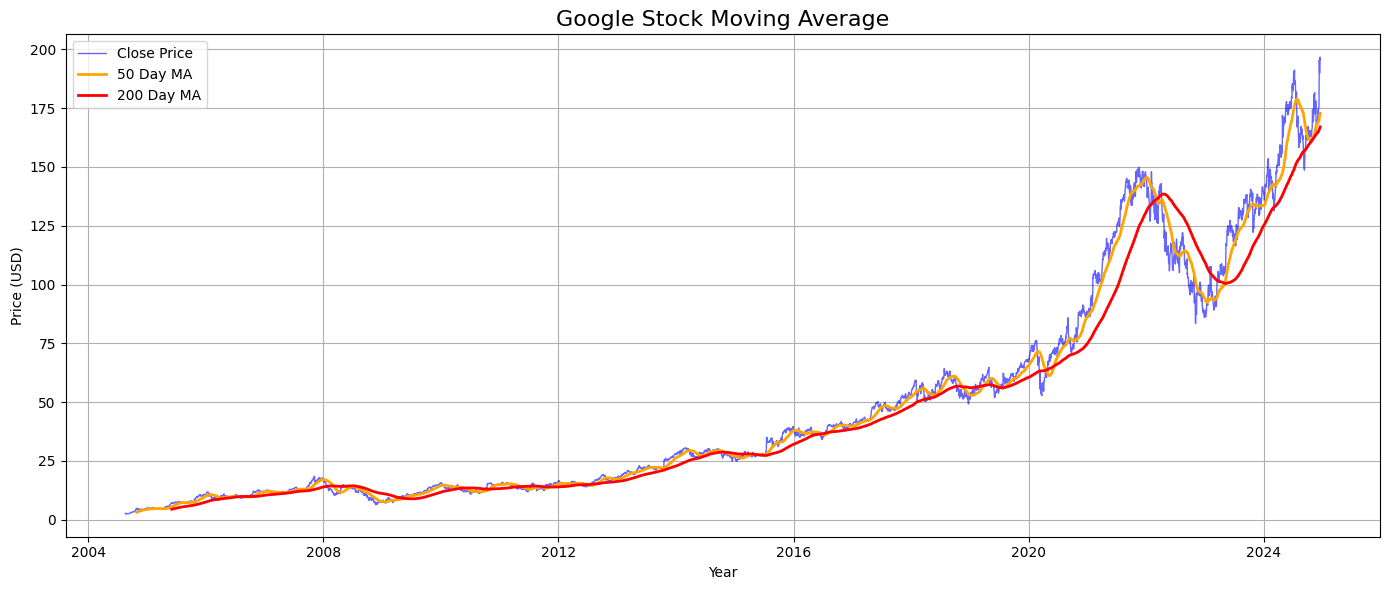

In [12]:
# Chart 6 - Moving Average
# Moving average smooths out price fluctuations
# 50 day MA = average of last 50 days price
# 200 day MA = average of last 200 days price
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'],
         color='blue', label='Close Price',
         linewidth=1, alpha=0.6)
plt.plot(df['Date'], df['MA50'],
         color='orange', label='50 Day MA', linewidth=2)
plt.plot(df['Date'], df['MA200'],
         color='red', label='200 Day MA', linewidth=2)
plt.title("Google Stock Moving Average", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# Project Conclusion
print("""
===========================================
   GOOGLE STOCK MARKET ANALYSIS
   CONCLUSION
===========================================

1. DATASET OVERVIEW:
   - Company: Google (GOOGL)
   - Period: 2004 to 2024 (20 Years)
   - Total Trading Days: 5,118
   - Features: Open, High, Low, Close, Volume

2. DATA CLEANING:
   - Zero missing values found
   - Date converted to proper format
   - Data sorted from oldest to newest

3. KEY INSIGHTS:

   PRICE GROWTH:
   - 2004 price: ~$2.50
   - 2024 price: ~$197
   - Total growth: 7800% in 20 years!

   TRADING VOLUME:
   - Highest volume in 2004-2008
   - Volume decreased as stock stabilized
   - Early investors were most active!

   CORRELATION:
   - All price columns perfectly correlated
   - Volume negatively correlated with price
   - When price rises, volume decreases!

   MOVING AVERAGE:
   - MA50 above MA200 = Bullish trend!
   - 2020 COVID crash clearly visible
   - Strong recovery after 2020!

4. CONCLUSION:
   - Google is one of best performing stocks!
   - 20 year growth of 7800% is exceptional!
   - Strong upward trend continuing in 2024!
   - Excellent long term investment!
===========================================
""")


   GOOGLE STOCK MARKET ANALYSIS
   CONCLUSION

1. DATASET OVERVIEW:
   - Company: Google (GOOGL)
   - Period: 2004 to 2024 (20 Years)
   - Total Trading Days: 5,118
   - Features: Open, High, Low, Close, Volume

2. DATA CLEANING:
   - Zero missing values found
   - Date converted to proper format
   - Data sorted from oldest to newest

3. KEY INSIGHTS:

   PRICE GROWTH:
   - 2004 price: ~$2.50
   - 2024 price: ~$197
   - Total growth: 7800% in 20 years!

   TRADING VOLUME:
   - Highest volume in 2004-2008
   - Volume decreased as stock stabilized
   - Early investors were most active!

   CORRELATION:
   - All price columns perfectly correlated
   - Volume negatively correlated with price
   - When price rises, volume decreases!

   MOVING AVERAGE:
   - MA50 above MA200 = Bullish trend!
   - 2020 COVID crash clearly visible
   - Strong recovery after 2020!

4. CONCLUSION:
   - Google is one of best performing stocks!
   - 20 year growth of 7800% is exceptional!
   - Strong upward tren